# Week 2 — End-to-End ML Pipeline
Preprocessing -> EDA -> Feature Engineering -> Regression -> Hyperparameter Tuning -> Time Series (ARIMA).

**Target:** `Estimated_Deliveries`

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA   # for the time-series part

In [2]:
# Colab upload (skip this cell if running locally / on Kaggle)
from google.colab import files
uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 1. Inspect the data

In [4]:
print("Shape:", df.shape)
print()
df.info()
print()
print("Nulls per column:")
print(df.isnull().sum())

Shape: (2640, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Nulls per column:
Year                    0
Month                   0
Region                  0

In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 2. Cleaning
This dataset has **no nulls and no duplicates**, but we keep the steps so the pipeline is robust.
Note: `fillna(method='ffill')` is deprecated in pandas 2.x -> use `df.ffill()`.

In [6]:
df = df.drop_duplicates()
df = df.ffill()   # safe no-op here, but correct modern syntax
print("After cleaning:", df.shape, "| nulls:", int(df.isnull().sum().sum()))

After cleaning: (2640, 12) | nulls: 0


## 3. EDA

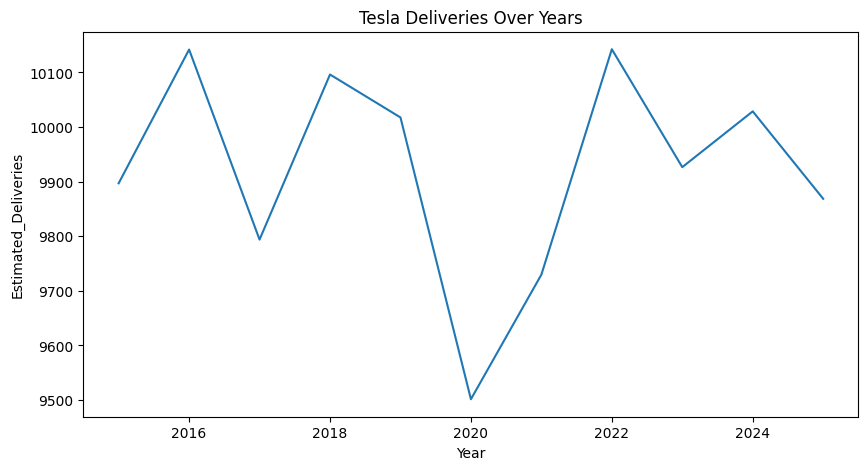

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Year", y="Estimated_Deliveries", errorbar=None)
plt.title("Tesla Deliveries Over Years")
plt.show()

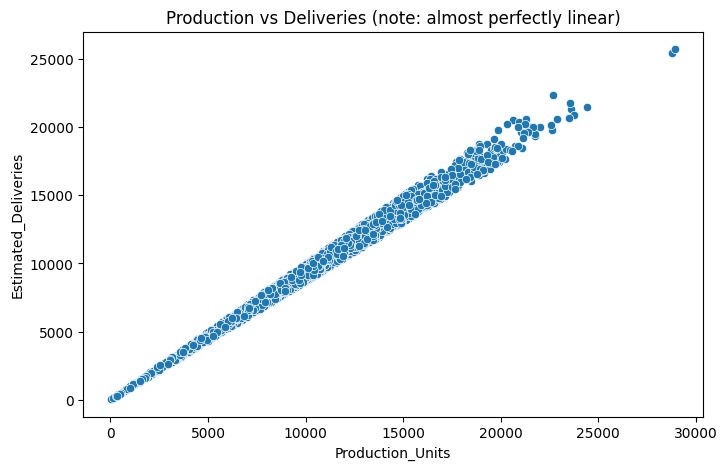

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries")
plt.title("Production vs Deliveries (note: almost perfectly linear)")
plt.show()

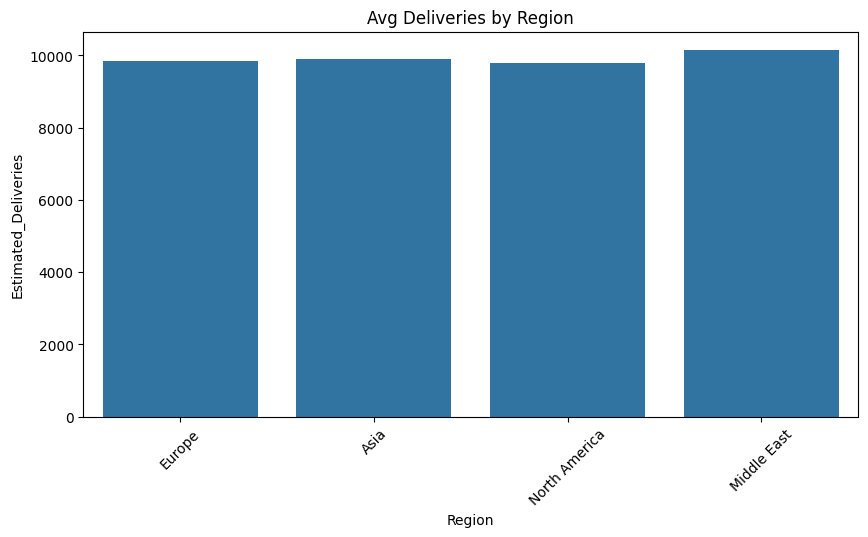

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Region", y="Estimated_Deliveries", errorbar=None)
plt.title("Avg Deliveries by Region")
plt.xticks(rotation=45)
plt.show()

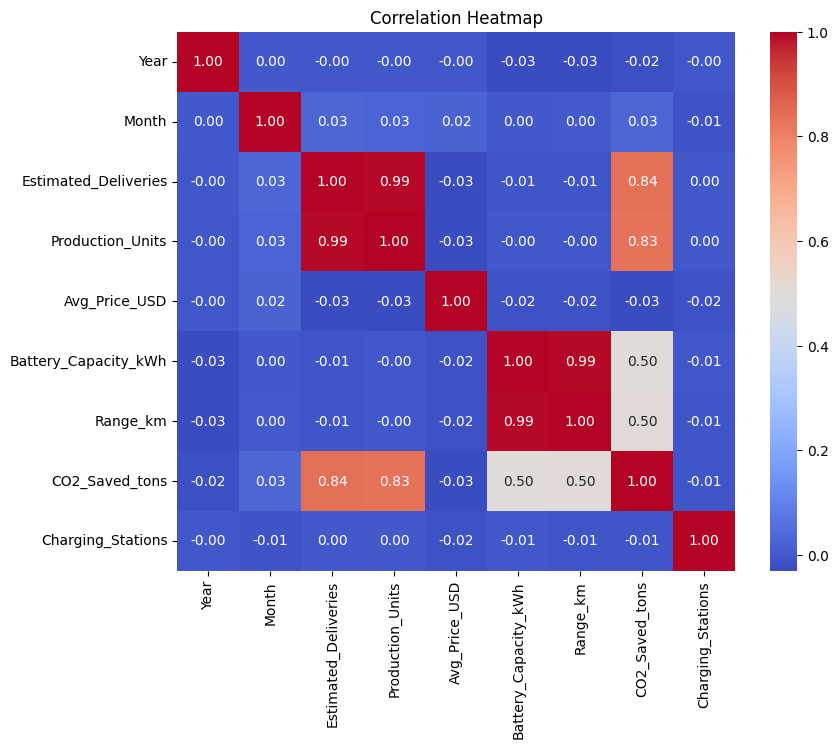

In [10]:
# quick correlation heatmap on numeric columns
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 4. Feature Engineering
We create `Efficiency` and `Revenue` for **analysis only**.

**They are NOT used as model inputs.** Both are computed *from the target* (`Revenue = Deliveries * Price`, `Efficiency = Deliveries / Production`), so feeding them into `X` leaks the answer and gives a fake R2 ~ 0.999. Lag/rolling features belong to the time-series section, so we keep them out of the regression too.

In [11]:
df["Efficiency"] = df["Estimated_Deliveries"] / df["Production_Units"]
df["Revenue"]    = df["Estimated_Deliveries"] * df["Avg_Price_USD"]

# inspect, but remember: these LEAK the target -> excluded from X below
df[["Estimated_Deliveries","Efficiency","Revenue"]].head()

,Estimated_Deliveries,Efficiency,Revenue
0,17646,0.984600,1.638859e+09
1,3797,0.911864,2.361949e+08
2,8411,0.915334,9.915502e+08
3,6555,0.896594,5.853281e+08
4,12374,0.914087,1.421114e+09


## 5. Encode categoricals + build X / y

In [12]:
for col in ["Region", "Model", "Source_Type"]:
    df[col] = LabelEncoder().fit_transform(df[col])

In [13]:
# Genuine predictors only - no target-derived (leaky) columns
feature_cols = [
    "Year", "Month", "Region", "Model", "Production_Units",
    "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km",
    "CO2_Saved_tons", "Source_Type", "Charging_Stations",
]
X = df[feature_cols]
y = df["Estimated_Deliveries"]
print("X shape:", X.shape)

X shape: (2640, 11)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)

## 6. Regression - Linear Regression

In [16]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

print("Linear Regression")
print("MAE :", round(mean_absolute_error(y_test, lr_pred), 2))
print("R2  :", round(r2_score(y_test, lr_pred), 4))

Linear Regression
MAE : 310.13
R2  : 0.9901


In [17]:
scores = cross_val_score(lr, X_train_s, y_train, cv=5, scoring="r2")
print("5-fold CV R2:", round(scores.mean(), 4))

5-fold CV R2: 0.9903


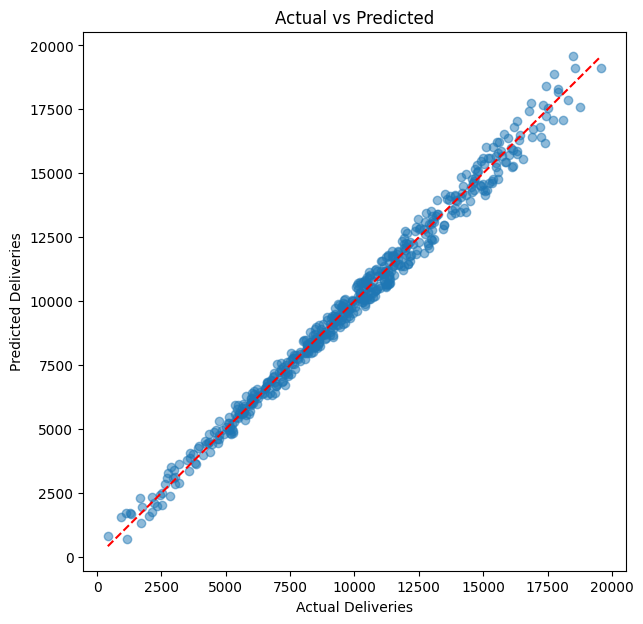

In [18]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, lr_pred, alpha=0.5)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")        # perfect-prediction line
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted")
plt.show()

## 7. Hyperparameter Tuning
A small `GridSearchCV` over a `RandomForestRegressor`. Trees don't need scaling, so we use the raw `X_train`. This is the part your `params` grid was meant for - now it actually runs.

In [19]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R2 :", round(grid.best_score_, 4))
print("Test R2    :", round(r2_score(y_test, grid.predict(X_test)), 4))

Best params: {'max_depth': 10, 'n_estimators': 100}
Best CV R2 : 0.988
Test R2    : 0.9885


## 8. Time Series Forecasting
The raw rows are in random order, so lag features on them are meaningless. For forecasting we first build a **proper monthly series**: total deliveries per `Year-Month`, sorted by time. Then a simple `ARIMA(1,1,1)` and a 6-month hold-out.

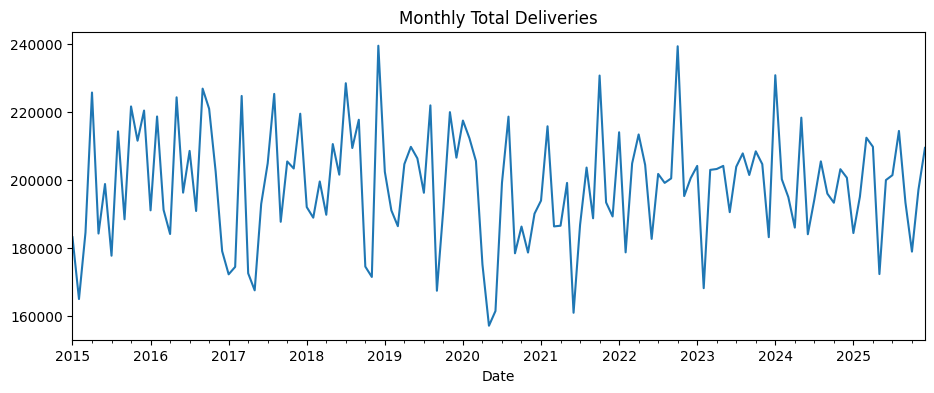

Months: 132


In [20]:
ts = (
    df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum()
      .reset_index()
      .sort_values(["Year", "Month"])
)
ts["Date"] = pd.to_datetime(dict(year=ts.Year, month=ts.Month, day=1))
ts = ts.set_index("Date")["Estimated_Deliveries"].asfreq("MS")

plt.figure(figsize=(11,4))
ts.plot()
plt.title("Monthly Total Deliveries")
plt.show()
print("Months:", len(ts))

ARIMA(1,1,1) test MAE: 9560.89


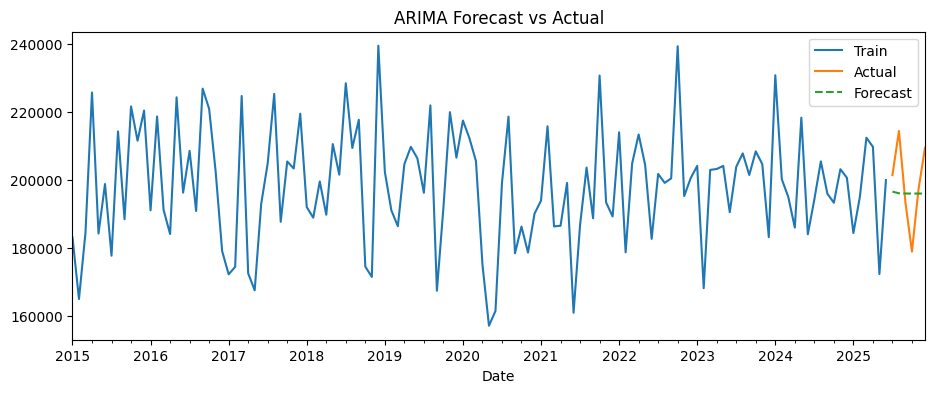

In [21]:
train, test = ts[:-6], ts[-6:]   # last 6 months held out

model = ARIMA(train, order=(1, 1, 1)).fit()
forecast = model.forecast(steps=len(test))

print("ARIMA(1,1,1) test MAE:", round(mean_absolute_error(test, forecast), 2))

plt.figure(figsize=(11,4))
train.plot(label="Train")
test.plot(label="Actual")
forecast.plot(label="Forecast", style="--")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()